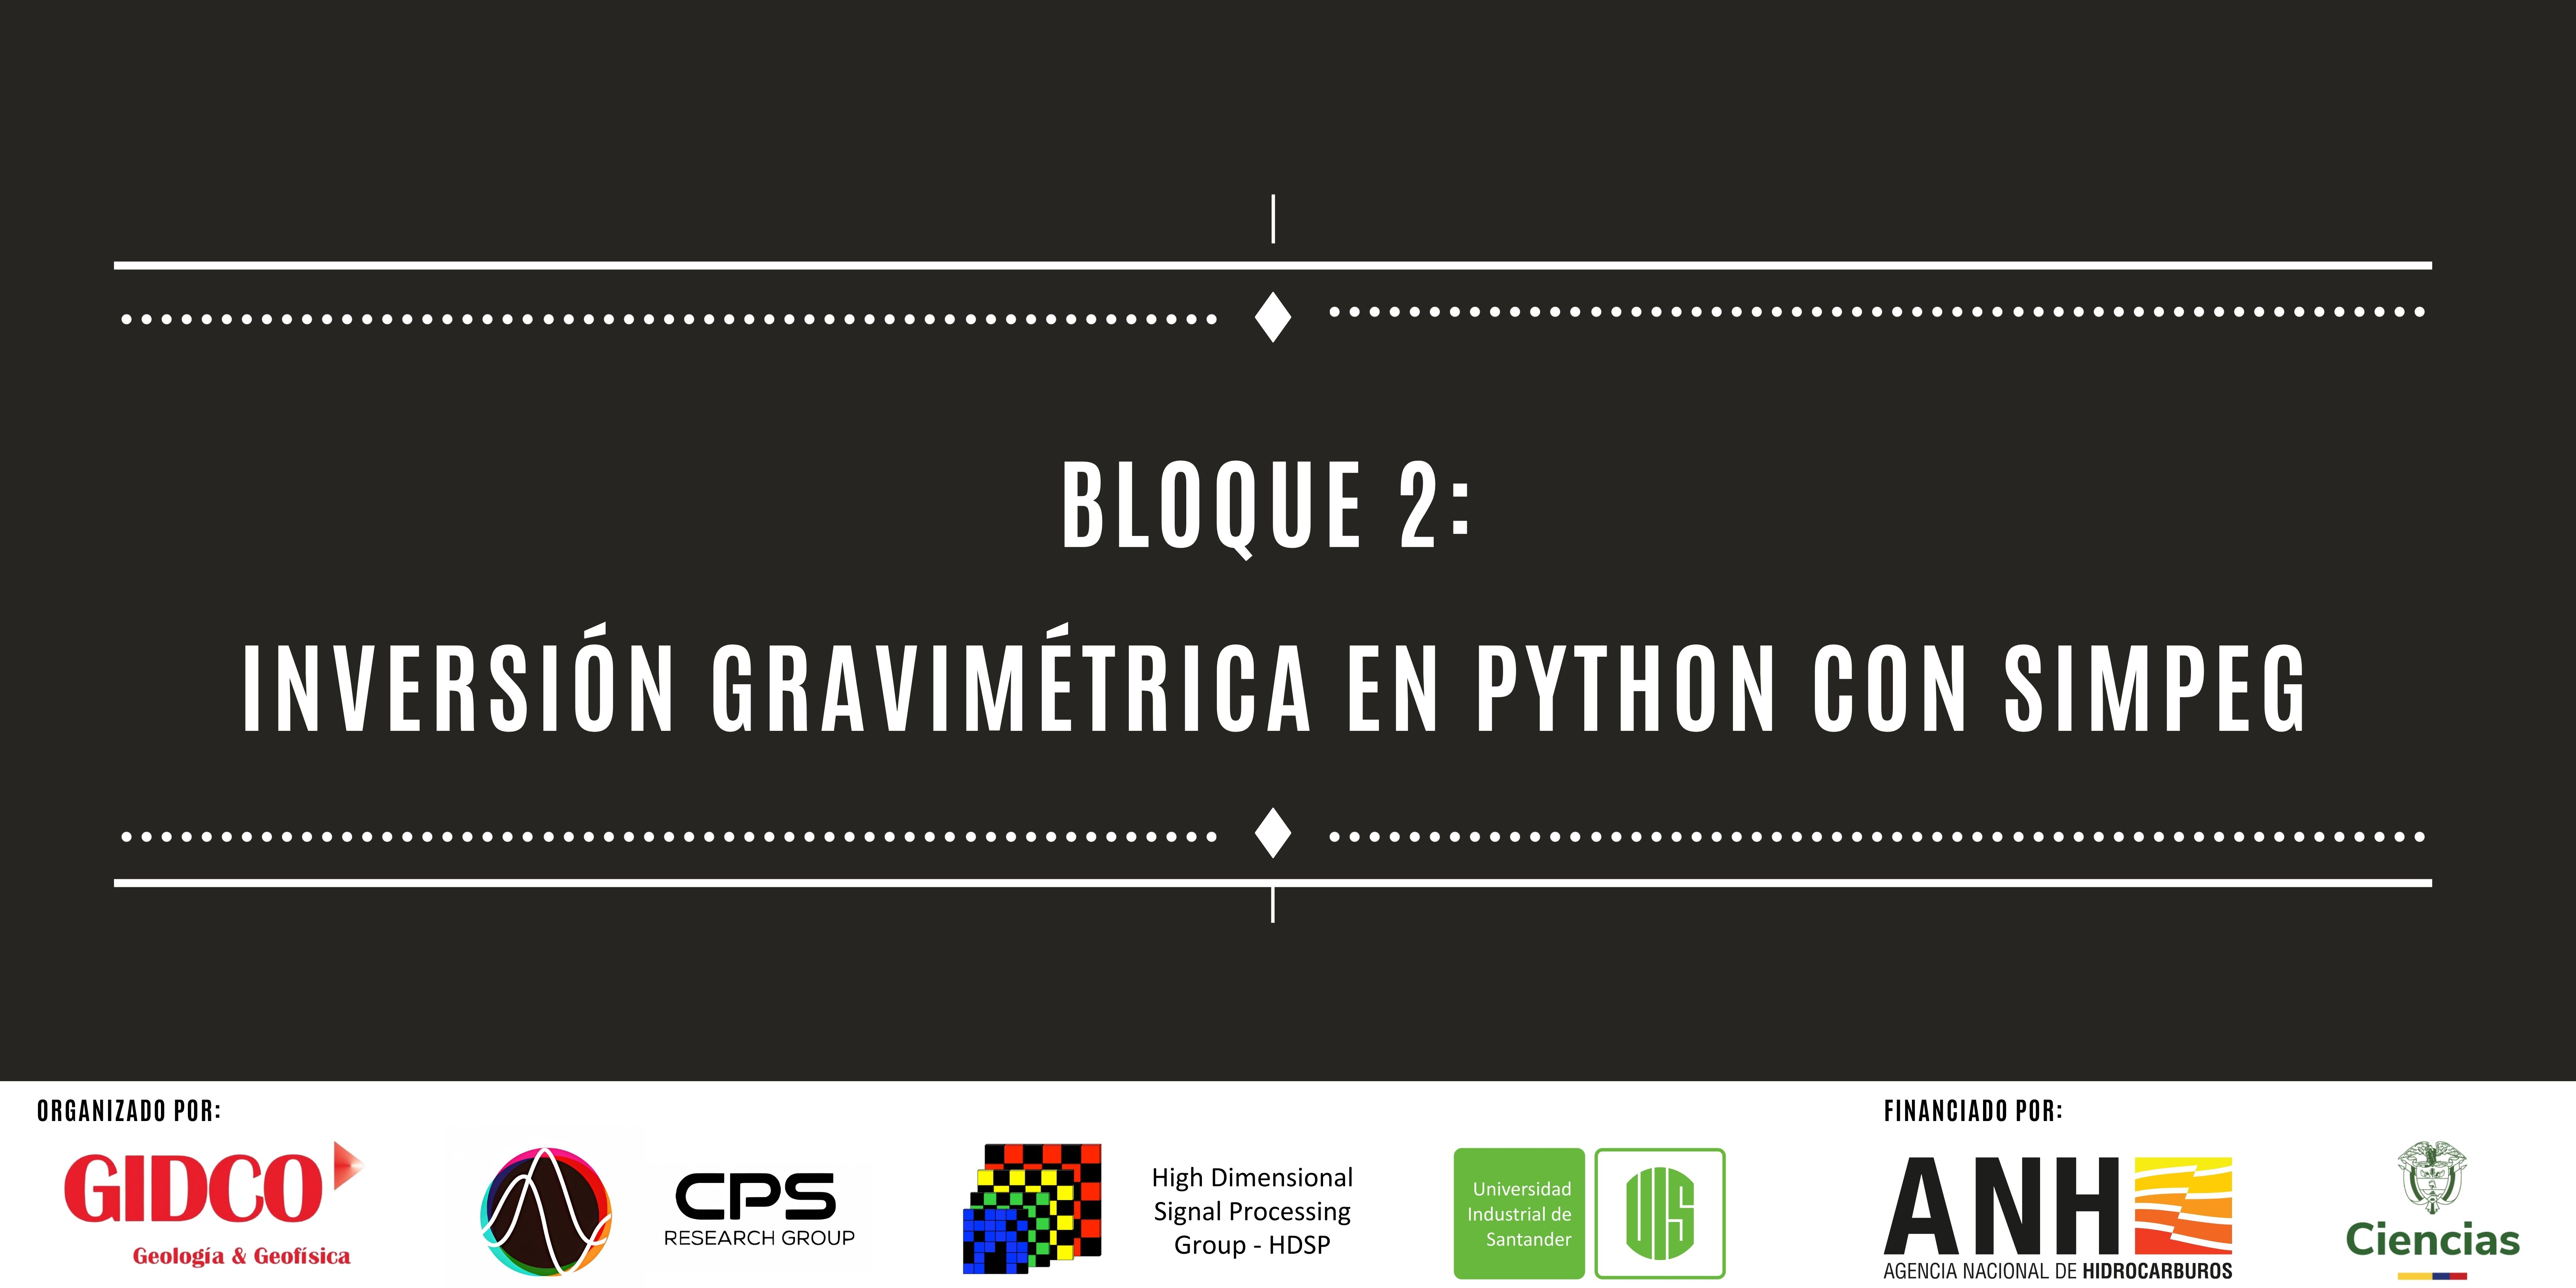

# Inversión gravimétrica sintética 3D con SimPEG (flujo completo)

## Lo que vas a aprender
1. Cargar datos sintéticos y topografía  
2. Definir el *survey* y el objeto `Data`  
3. Construir malla 3D y celdas activas bajo topografía  
4. Formular: **misfit + regularización** (Sparse + *depth weighting*)  
5. Ejecutar una inversión y validar:
   - ajuste a datos (RMSE, MAE)
   - recuperación del modelo (slice + métricas)

**Convención:** datos en **mGal** y contraste de densidad en **g/cm³**.

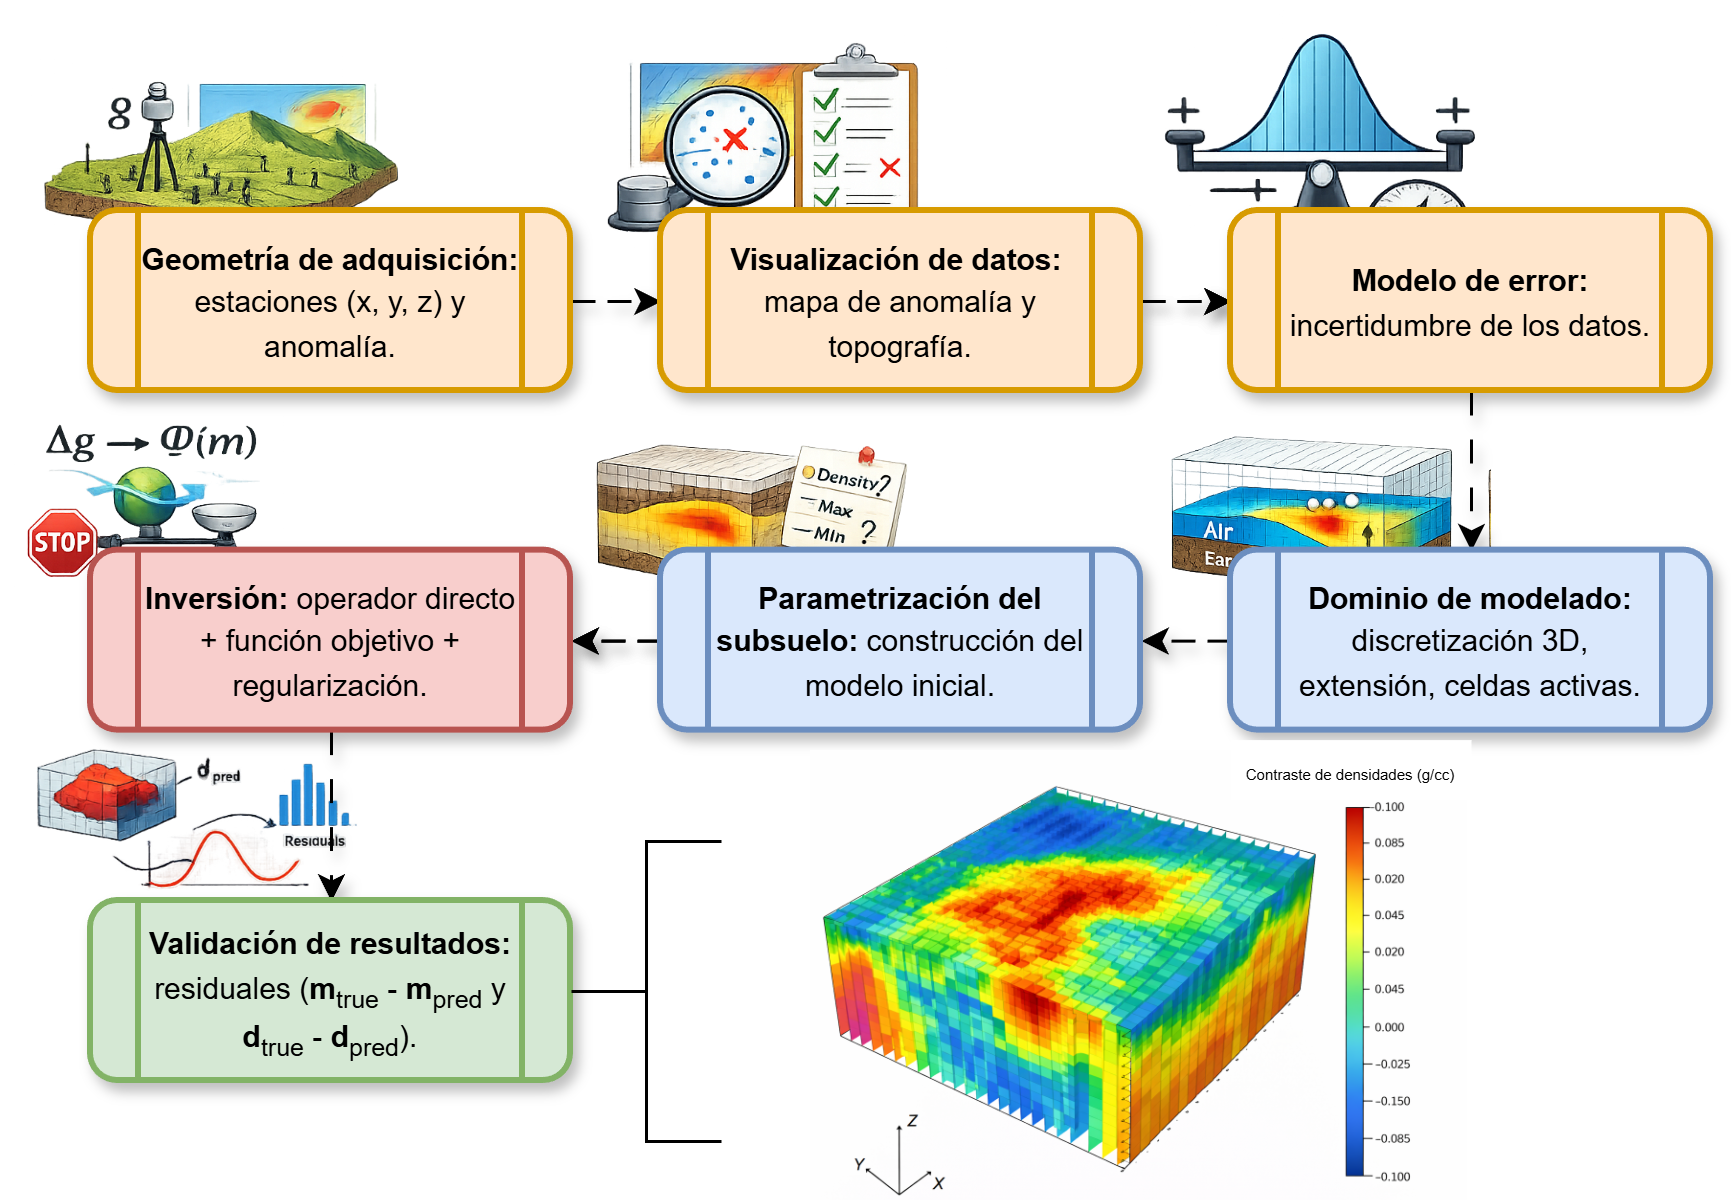

In [ ]:
#!pip install simpeg

In [ ]:
#@title 0) Preparación del entorno e importación de librerías (plegable)
# Si necesitas instalar (una sola vez):
# !pip -q install simpeg

import os
import tarfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from discretize import TensorMesh
from discretize.utils import active_from_xyz

from simpeg import (
    data,
    data_misfit,
    directives,
    inverse_problem,
    inversion,
    maps,
    optimization,
    regularization,
    utils,
)
from simpeg.potential_fields import gravity
from simpeg.utils import model_builder, plot2Ddata

mpl.rcParams.update({"font.size": 12})

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1. Descarga del dataset del tutorial

Usaremos un conjunto de datos de ejemplo (SimPEG *doc-assets*) que incluye:

- `gravity_topo.txt`: topografía (x, y, z).
- `gravity_data.obs`: observaciones (x, y, z, dato).

La idea es enfocarnos en el flujo de inversión, no en preparar el dataset desde cero.


In [ ]:
# @title
data_source = "https://storage.googleapis.com/simpeg/doc-assets/gravity.tar.gz"
downloaded_data = utils.download(data_source, overwrite=True)

tar = tarfile.open(downloaded_data, "r")
tar.extractall()
tar.close()

dir_path = downloaded_data.split(".")[0] + os.path.sep

topo_filename = dir_path + "gravity_topo.txt"
data_filename = dir_path + "gravity_data.obs"

xyz_topo = np.loadtxt(str(topo_filename))         # (N,3)
dobs_all = np.loadtxt(str(data_filename))         # (N,4) -> x,y,z,data
receiver_locations = dobs_all[:, 0:3]
dobs = dobs_all[:, -1]

print("Topografía:", xyz_topo.shape)
print("Datos (obs):", dobs_all.shape)

df_topo = pd.DataFrame(xyz_topo, columns=["x", "y", "z"])
df_obs  = pd.DataFrame(dobs_all, columns=["x", "y", "z", "dobs_mGal"])

print("Topografía (primeras filas):")
display(df_topo.head(10))

print("Observaciones (primeras filas):")
display(df_obs.head(10))

overwriting /content/gravity.tar.gz
   saved to: /content/gravity.tar.gz
Download completed!
Topografía: (1681, 3)
Datos (obs): (289, 4)
Topografía (primeras filas):


/tmp/ipython-input-402/1494451919.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


,x,y,z
0,-200.0,-200.0,-0.000056
1,-200.0,-190.0,-0.000103
2,-200.0,-180.0,-0.000183
3,-200.0,-170.0,-0.000317
4,-200.0,-160.0,-0.000530
5,-200.0,-150.0,-0.000861
6,-200.0,-140.0,-0.001354
7,-200.0,-130.0,-0.002065
8,-200.0,-120.0,-0.003052
9,-200.0,-110.0,-0.004372


Observaciones (primeras filas):


,x,y,z,dobs_mGal
0,-80.0,-80.0,2.97000,0.000871
1,-70.0,-80.0,2.43380,0.000826
2,-60.0,-80.0,1.85580,0.000950
3,-50.0,-80.0,1.26620,0.000889
4,-40.0,-80.0,0.70243,0.000932
5,-30.0,-80.0,0.20571,0.000784
6,-20.0,-80.0,-0.18386,0.000658
7,-10.0,-80.0,-0.43264,0.000429
8,0.0,-80.0,-0.51819,0.000143
9,10.0,-80.0,-0.43264,-0.000004


## 2. Lectura e inspección visual de la anomalía observada

Antes de invertir, siempre conviene mirar los datos para entender:

- su rango (mínimo / máximo),
- la geometría del patrón,
- posibles valores atípicos.

Esto ayuda a validar que el dataset se cargó correctamente y a anticipar la dificultad del problema.


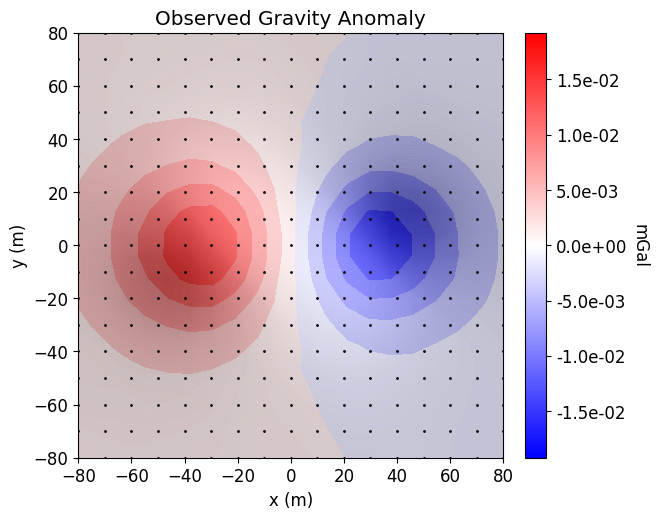

In [ ]:
# @title
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.85])

vmax_data = np.max(np.abs(dobs))
norm_data = mpl.colors.Normalize(vmin=-vmax_data, vmax=vmax_data)

plot2Ddata(
    receiver_locations,
    dobs,
    ax=ax1,
    contourOpts={"cmap": "bwr", "norm": norm_data},
    shade=True,
    nx=20,
    ny=20,
    dataloc=True,
)
ax1.set_title("Observed Gravity Anomaly")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.8, 0.1, 0.03, 0.85])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm_data, orientation="vertical", cmap=mpl.cm.bwr, format="%.1e"
)
cbar.set_label("mGal", rotation=270, labelpad=15, size=12)

plt.show()

## 3. Incertidumbres y pesos en datos (notación tipo GIFtools)

Misfit ponderado:
$$
\phi_d(\mathbf{m})=
\sum_{i=1}^{N}\left(\frac{F(\mathbf{m})_i-d_i}{\varepsilon_i}\right)^2
=
\left\|\mathbf{W}_d\left(\mathbf{d}-\mathbf{F}(\mathbf{m})\right)\right\|_2^2,
\qquad
\mathbf{W}_d=\mathrm{diag}(\varepsilon_i^{-1})
$$

Aquí usamos un esquema simple: $\varepsilon_i$ constante para todos los datos
(a partir de un porcentaje del máximo).

In [ ]:
NOISE_FRAC = 0.01  #@param {type:"number", min:0, max:0.1, step:0.001}

maximum_anomaly = np.max(np.abs(dobs))
uncertainties = NOISE_FRAC * maximum_anomaly * np.ones_like(dobs)

## 4. Definición del survey y del objeto `Data`

Construimos el experimento de gravedad:

- receptores en `receiver_locations`,
- componente medida: **gz** (anomalía vertical),
- y empaquetamos `dobs` + `σ` dentro de un objeto `Data`.

A partir de aquí, SimPEG ya conoce geometría, valores observados y nivel de ruido.

In [ ]:
receiver_list = gravity.receivers.Point(receiver_locations, components="gz")
survey = gravity.survey.Survey(gravity.sources.SourceField(receiver_list=[receiver_list]))
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

## 5. Discretización del subsuelo: malla tensorial 3D

Creamos una `TensorMesh` con:

- celdas más finas en la zona central (donde esperamos estructura),
- *padding* hacia los bordes para reducir efectos de borde.

La inversión estimará un parámetro por celda **activa** (debajo de la topografía).


In [ ]:
dh = 5.0  #@param {type:"number", min:1, max:50, step:1}

pad_cells = 5   #@param {type:"integer", min:1, max:20, step:1}
core_cells = 40 #@param {type:"integer", min:10, max:150, step:5}

pad_rate = 1.3  #@param {type:"number", min:1.05, max:2.0, step:0.05}

nz_pad = 5      #@param {type:"integer", min:1, max:30, step:1}
nz_core = 15    #@param {type:"integer", min:5, max:80, step:5}

hx = [(dh, pad_cells, -pad_rate), (dh, core_cells), (dh, pad_cells, pad_rate)]
hy = [(dh, pad_cells, -pad_rate), (dh, core_cells), (dh, pad_cells, pad_rate)]
hz = [(dh, nz_pad,   -pad_rate), (dh, nz_core)]
mesh = TensorMesh([hx, hy, hz], "CCN")

## 6. Celdas activas, mapeo y modelo inicial

Activamos solo las celdas **bajo la topografía** (modelo físicamente interpretable).

Luego definimos:

- `model_map`: identidad (un valor por celda activa),
- `starting_model`: modelo inicial (aquí, cero).

In [ ]:
ind_active = active_from_xyz(mesh, xyz_topo)   # below topo
nC = int(ind_active.sum())

model_map = maps.IdentityMap(nP=nC)
starting_model = np.zeros(nC)

### Corte 2D: topografía + malla + celdas activas (qué se invierte y qué no)

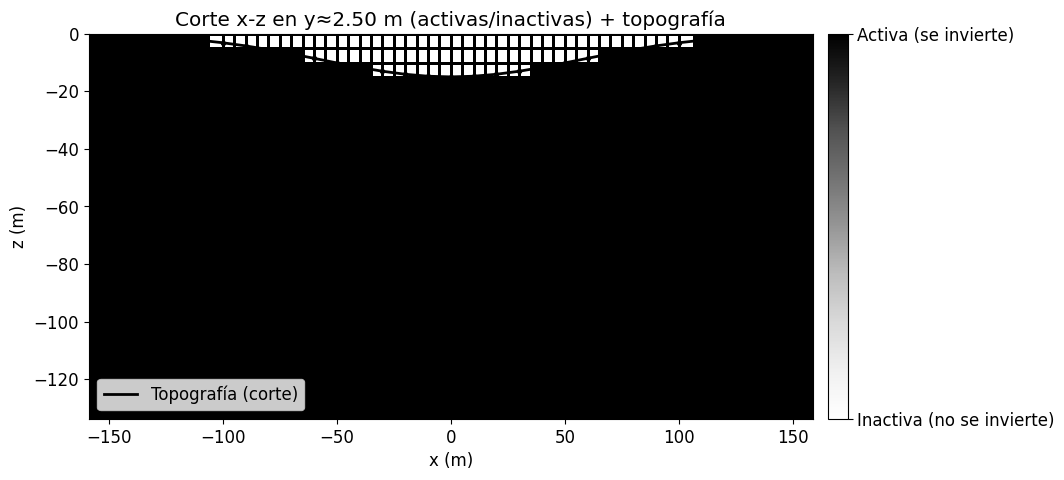

In [ ]:
SLICE_Y_LOC = 0.0  #@param {type:"number", min:-200, max:200, step:5}

y_centers = mesh.cell_centers[:, 1]
y0 = y_centers[np.argmin(np.abs(y_centers - SLICE_Y_LOC))]

active_full = np.zeros(mesh.nC)
active_full[ind_active] = 1.0

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

out = mesh.plot_slice(
    active_full,
    normal="Y",
    slice_loc=y0,
    ax=ax,
    grid=True,
    pcolor_opts={"cmap": "Greys", "vmin": 0, "vmax": 1},
)
cbar = plt.colorbar(out[0], ax=ax, fraction=0.046, pad=0.02)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Inactiva (no se invierte)", "Activa (se invierte)"])

tol = max(mesh.h[1].min(), 5.0)
mask_topo = np.abs(xyz_topo[:, 1] - y0) < tol
topo_cut = xyz_topo[mask_topo]

if topo_cut.shape[0] > 5:
    topo_cut = topo_cut[np.argsort(topo_cut[:, 0])]
    ax.plot(topo_cut[:, 0], topo_cut[:, 2], "k-", lw=2, label="Topografía (corte)")
    ax.scatter(topo_cut[:, 0], topo_cut[:, 2], s=8, c="k")
    ax.legend(loc="lower left")
else:
    ax.text(
        0.02, 0.95,
        "Pocos puntos de topografía en este corte.\nPrueba otro SLICE_Y_LOC.",
        transform=ax.transAxes, va="top"
    )

ax.set_title(f"Corte x-z en y≈{y0:.2f} m (activas/inactivas) + topografía")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
plt.show()

## Operador directo de gravimetría (gz)

Forma continua (componente vertical):
$$
d_i=g_z(\mathbf{r}_i)=
G\int_V \Delta\rho(\mathbf{r}')
\frac{(z_i-z')}{\|\mathbf{r}_i-\mathbf{r}'\|^3}\,dV'
$$

Discretización (modelo por celda):
$$
\mathbf{d}=\mathbf{G}\mathbf{m}
$$

- $\mathbf{m}$: contraste de densidad en celdas activas  
- $\mathbf{G}$: sensibilidad (kernel) que depende de geometría (receptores + malla + activas)  
- `Simulation3DIntegral` implementa este mapeo $\mathbf{m}\mapsto \mathbf{d}_{pred}$ (sin que tú construyas $\mathbf{G}$ explícitamente)

## 7. Problema directo (forward) y función de desajuste


In [ ]:
simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey, mesh=mesh, rhoMap=model_map, active_cells=ind_active
)

dmis = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

## 8. Formulación de la inversión
Resolvemos el problema:

$$
\phi(\mathbf{m})=\phi_d(\mathbf{m})+\beta\,\phi_m(\mathbf{m})
$$



### 8.1 Regularización

$$
\begin{split}
\phi_m(\mathbf{m})=&\
\alpha_s \|\mathbf{W_s}\mathbf{R}_s(\mathbf{m}-\mathbf{m}_{ref})\|_2^2
+ \alpha_x \|\mathbf{W_x}\mathbf{R}_x\mathbf{G}_x(\mathbf{m}-\mathbf{m}_{ref})\|_2^2\\
&+ \alpha_y \|\mathbf{W_y}\mathbf{R}_y\mathbf{G}_y(\mathbf{m}-\mathbf{m}_{ref})\|_2^2
+ \alpha_z \|\mathbf{W_z}\mathbf{R}_z\mathbf{G}_z(\mathbf{m}-\mathbf{m}_{ref})\|_2^2
\end{split}
$$

En el código:
- `regularization.Sparse(...)` construye smallness + gradientes
- `reg.norms = [...]` define normas (sparse via IRLS)
- `reg.set_weights(depth_weights=...)` aplica un peso tipo profundidad/distancia

In [ ]:
# --- Sparse norms ---
smallness_norm = 0  #@param {type:"integer", min:0, max:2, step:1}
grad_norm = 2       #@param {type:"integer", min:0, max:2, step:1}

# --- Depth weighting ---
DEPTH_EXPONENT = 2  #@param {type:"integer", min:0, max:6, step:1}

reg = regularization.Sparse(mesh, active_cells=ind_active, mapping=model_map)
reg.norms = [smallness_norm, grad_norm, grad_norm, grad_norm]

depth_weights = utils.depth_weighting(
    mesh, receiver_locations, active_cells=ind_active, exponent=DEPTH_EXPONENT
)
reg.set_weights(depth_weights=depth_weights)

### 8.2 Optimizador (Projected Gauss-Newton + CG) con bounds
$$
m_{min}\le m \le m_{max}
$$

In [ ]:
LOWER = -1.0  #@param {type:"number", min:-5, max:0, step:0.1}
UPPER =  1.0  #@param {type:"number", min:0, max:5, step:0.1}

MAXITER = 100     #@param {type:"integer", min:10, max:300, step:10}
MAXITER_LS = 20   #@param {type:"integer", min:5, max:100, step:5}
CG_MAXITER = 10   #@param {type:"integer", min:5, max:200, step:5}
CG_RTOL = 1e-3    #@param {type:"number"}

opt = optimization.ProjectedGNCG(
    maxIter=MAXITER,
    lower=LOWER, upper=UPPER,
    maxIterLS=MAXITER_LS,
    cg_maxiter=CG_MAXITER,
    cg_rtol=CG_RTOL
)

### 8.3 Directivas (β, IRLS, precondicionador)

In [ ]:
IRLS_MAX = 30          #@param {type:"integer", min:1, max:100, step:1}
IRLS_COOL = 1.5        #@param {type:"number", min:1.0, max:3.0, step:0.1}
IRLS_FMIN = 1e-4       #@param {type:"number"}
IRLS_MISFIT_TOL = 1e-2 #@param {type:"number"}

BETA0_RATIO = 1.0  #@param {type:"number", min:1e-3, max:100, step:0.1}

starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=BETA0_RATIO)

update_IRLS = directives.UpdateIRLS(
    f_min_change=IRLS_FMIN,
    max_irls_iterations=IRLS_MAX,
    irls_cooling_factor=IRLS_COOL,
    misfit_tolerance=IRLS_MISFIT_TOL,
)

save_iteration = directives.SaveOutputEveryIteration(on_disk=False)
update_jacobi = directives.UpdatePreconditioner()

directives_list = [update_IRLS, starting_beta, save_iteration, update_jacobi]

### 8.4 Ensamble y corrida de la inversión

In [ ]:
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)
inv = inversion.BaseInversion(inv_prob, directives_list)

recovered_model = inv.run(starting_model)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO:SimPEG:simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO:SimPEG:simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO:SimPEG:simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO:SimPEG:simpeg.InvProblem will set Regularization.reference_model to m0.



Running inversion with SimPEG v0.25.1
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.05e+03  2.66e+05  0.00e+00  2.66e+05                         0           inf          inf                
   1  1.05e+03  3.52e+03  1.68e+01  2.11e+04    2.18e+02      0      10       1.93e-03     1.55e+03              
   2  5.24e+02  1.33e+03  1.97e+01  1.16e+04    2.11e+02      0      10       1.27e-02     3.26e+02              
   3  2.62e+02  5.07e+02  2.18e+01  6.22e+03    2.05e+02      0      10       2.87e-02     4.04e+02              
   4  1.31e+02  2.01e+02  2.34e+01  3.27e+03    1.96e+02      0      10       5.82e-02     4.37e+02              
Reached starting chifact with l2-norm regulariza

## 9. Modelo verdadero (ground truth) para comparar

Como el ejemplo es sintético, conocemos el modelo real. Lo reconstruimos con dos anomalías:

- **bloque** (contraste negativo),
- **esfera** (contraste positivo).

Esto nos permite evaluar la inversión no solo por ajuste a datos, sino por recuperación de geometría y amplitudes.


In [ ]:
# @title
background_density = 0.0
block_density = -0.2
sphere_density = 0.2

true_model = background_density * np.ones(nC)

cc = mesh.gridCC  # (n_mesh_cells, 3)
cc_act = cc[ind_active]

ind_block = (
    (cc_act[:, 0] > -50.0) & (cc_act[:, 0] < -20.0)
    & (cc_act[:, 1] > -15.0) & (cc_act[:, 1] < 15.0)
    & (cc_act[:, 2] > -50.0) & (cc_act[:, 2] < -30.0)
)
true_model[ind_block] = block_density

ind_sphere_full = model_builder.get_indices_sphere(
    np.r_[35.0, 0.0, -40.0], 15.0, cc
)
ind_sphere = ind_sphere_full[ind_active]
true_model[ind_sphere] = sphere_density

## 10. Comparación en el espacio de datos: `dobs` vs `dpred`

Con el modelo recuperado calculamos:

- `dpred`: datos predichos por el forward,
- `res = dobs - dpred`: residuales.

Reportamos métricas típicas:

- **RMSE** y **MAE** (mGal),
- $\chi^2_{red}$ (ideal $\approx 1$ si $\sigma$ representa bien el ruido).

In [ ]:
# @title
dpred = simulation.dpred(recovered_model)
res = dobs - dpred

rmse = np.sqrt(np.mean(res**2))
mae = np.mean(np.abs(res))
chi2 = np.sum((res / uncertainties) ** 2)
chi2_red = chi2 / dobs.size

print("=== DATA FIT METRICS ===")
print(f"RMSE      = {rmse:.4e} mGal")
print(f"MAE       = {mae:.4e} mGal")
print(f"chi2_red  = {chi2_red:.3f} (ideal ~ 1)")

=== DATA FIT METRICS ===
RMSE      = 2.0697e-04 mGal
MAE       = 1.7233e-04 mGal
chi2_red  = 1.161 (ideal ~ 1)


## 11. Mapas: observado, predicho y residual (con colorbars)

Visualizamos tres mapas:

1) **Observed**: datos medidos  
2) **Predicted**: respuesta del modelo invertido  
3) **Residual**: estructura del error

Usamos la **misma escala** para observado y predicho (comparación justa) y una escala propia para el residual.


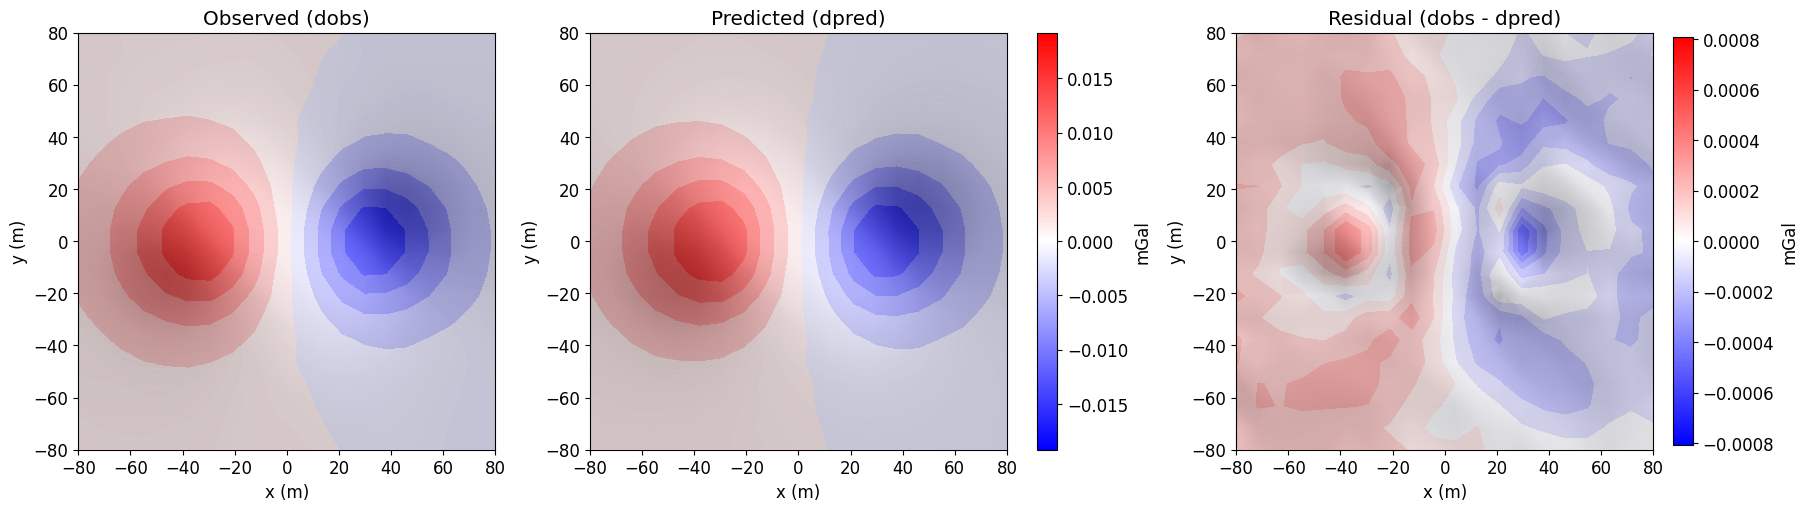

In [ ]:
# @title
fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

vmax_d = np.max(np.abs(np.r_[dobs, dpred]))
norm_d = mpl.colors.Normalize(vmin=-vmax_d, vmax=vmax_d)

plot2Ddata(
    receiver_locations, dobs, ax=axs[0],
    contourOpts={"cmap": "bwr", "norm": norm_d},
    shade=True, nx=20, ny=20, dataloc=False
)
axs[0].set_title("Observed (dobs)")
axs[0].set_xlabel("x (m)"); axs[0].set_ylabel("y (m)")

plot2Ddata(
    receiver_locations, dpred, ax=axs[1],
    contourOpts={"cmap": "bwr", "norm": norm_d},
    shade=True, nx=20, ny=20, dataloc=False
)
axs[1].set_title("Predicted (dpred)")
axs[1].set_xlabel("x (m)"); axs[1].set_ylabel("y (m)")

vmax_r = np.max(np.abs(res))
norm_r = mpl.colors.Normalize(vmin=-vmax_r, vmax=vmax_r)

plot2Ddata(
    receiver_locations, res, ax=axs[2],
    contourOpts={"cmap": "bwr", "norm": norm_r},
    shade=True, nx=20, ny=20, dataloc=False
)
axs[2].set_title("Residual (dobs - dpred)")
axs[2].set_xlabel("x (m)"); axs[2].set_ylabel("y (m)")

sm_d = mpl.cm.ScalarMappable(norm=norm_d, cmap="bwr")
sm_d.set_array([])
cbar1 = fig.colorbar(sm_d, ax=axs[:2], fraction=0.046, pad=0.02)
cbar1.set_label("mGal")

sm_r = mpl.cm.ScalarMappable(norm=norm_r, cmap="bwr")
sm_r.set_array([])
cbar2 = fig.colorbar(sm_r, ax=axs[2], fraction=0.046, pad=0.02)
cbar2.set_label("mGal")

plt.show()

## 12. Comparación en el espacio del modelo (corte 2D)

Comparamos un corte del subsuelo (slice a `y = 0 m`) para:

- **true model**,
- **recovered model**.

Aquí usamos **colorbars independientes** para resaltar patrones aun si las amplitudes difieren.
Los contornos punteados del true sirven como referencia geométrica.


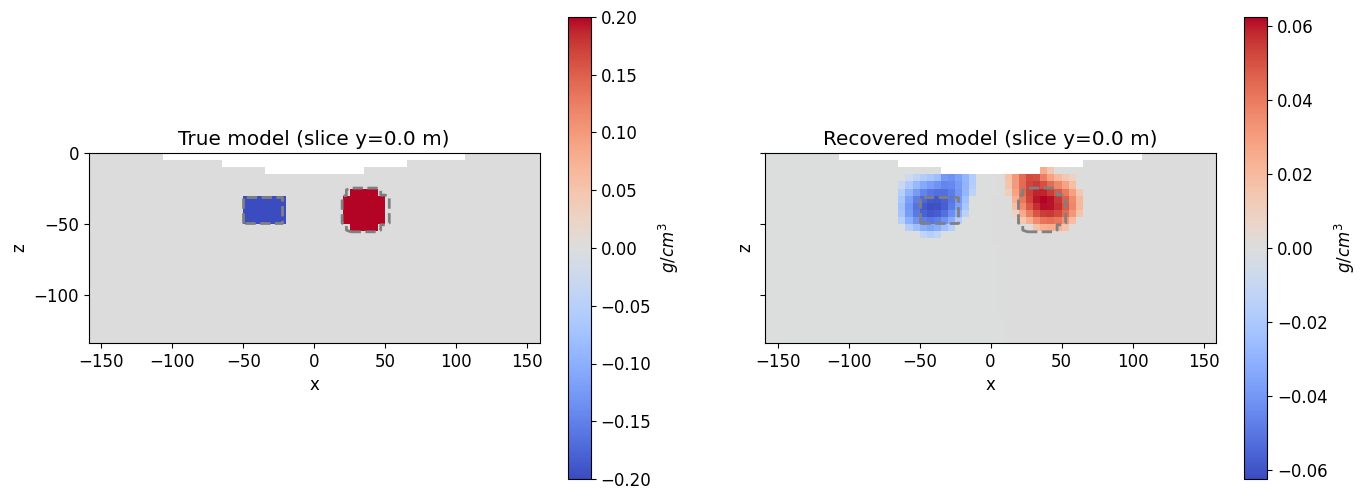

In [ ]:
SLICE_Y_LOC = 0.0  #@param {type:"number", min:-200, max:200, step:5}

plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)
cmap = "coolwarm"
slice_y_loc = SLICE_Y_LOC

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

vmax_true = np.nanmax(np.abs(true_model))
norm_true = mpl.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_true, vmax=vmax_true)

mm0 = mesh.plot_slice(
    plotting_map * true_model,
    normal="Y", ax=ax[0], grid=False, slice_loc=slice_y_loc,
    pcolor_opts={"cmap": cmap, "norm": norm_true},
)
ax[0].set_title(f"True model (slice y={slice_y_loc} m)")
plt.colorbar(mm0[0], ax=ax[0], label="$g/cm^3$")

vmax_rec = np.nanmax(np.abs(recovered_model))
norm_rec = mpl.colors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax_rec, vmax=vmax_rec)

mm1 = mesh.plot_slice(
    plotting_map * recovered_model,
    normal="Y", ax=ax[1], grid=False, slice_loc=slice_y_loc,
    pcolor_opts={"cmap": cmap, "norm": norm_rec},
)
ax[1].set_title(f"Recovered model (slice y={slice_y_loc} m)")
plt.colorbar(mm1[0], ax=ax[1], label="$g/cm^3$")

plotting_map0 = maps.InjectActiveCells(mesh, ind_active, 0.0)
slice_y_ind = (
    mesh.cell_centers[:, 1] == np.abs(mesh.cell_centers[:, 1] - slice_y_loc).min()
)

for axx in ax:
    utils.plot2Ddata(
        mesh.cell_centers[slice_y_ind][:, [0, 2]],
        (plotting_map0 * true_model)[slice_y_ind],
        contourOpts={"alpha": 0},
        level=True,
        ncontour=2,
        levelOpts={"colors": "grey", "linewidths": 2, "linestyles": "--"},
        method="nearest",
        ax=axx,
    )
    axx.set_aspect(1)

plt.show()

## 13. Métricas de modelo (error celda a celda)

Finalmente cuantificamos el error directo en las celdas activas:

- RMSE(model)
- MAE(model)

Esto complementa el ajuste a datos: un modelo puede ajustar bien y aun así no recuperar exactamente la geometría real.


In [ ]:
# @title
m_res = recovered_model - true_model
m_rmse = np.sqrt(np.mean(m_res**2))
m_mae  = np.mean(np.abs(m_res))

print("=== MODEL METRICS (active cells) ===")
print(f"RMSE(model) = {m_rmse:.4e} g/cc")
print(f"MAE(model)  = {m_mae:.4e} g/cc")

=== MODEL METRICS (active cells) ===
RMSE(model) = 1.2708e-02 g/cc
MAE(model)  = 1.5499e-03 g/cc
